# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ayesha-Shahzadkhan/flyrank-assignment1/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research Question: I want to know if a logistic regression model, trained on content signals can reliably predict which high‑visibility pages are at risk of performance decline. And whether it can beat a simple rule‑based baseline that uses impressions plus staleness thresholds to flag pages for refresh.

Decision it supports: The decision it supports is about which pages, in a content library should be prioritized for refresh versus left. It turns visibility and staleness data into a ranked action list that shows REFRESH, REVIEW or NO_ACTION for each page.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Primary dataset: content_refresh_anonymized.csv. This is the FlyRank ML Internship dataset with 30,000 rows and 44 columns. It contains content-performance data that was used to build the decline-prediction model using Logistic Regression, as well as its rule-based baseline.

Also explored: The FlyRank Warehouse Dataset (available on Hugging Face, gated production release) was used during Weeks 3 and 4 for exploratory aggregation and feature exploration at scale. However this dataset was not used in the trained model presented in this paper.

What was excluded and Why: The features trend_direction and trend_pct were excluded from the model. These features directly reflect the outcome being predicted. The decline. So including them would result in label leakage. They were kept to create the decline label, for verification purposes not for training.

Safe note: No client names, URLs or raw private queries appear in the dataset. All fields have been fully anonymized.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Assumptions: A page is considered to be declining when it shows signs of visibility together with low recent engagement or freshness. This follows the logic as the rule-based baseline but the model uses a larger set of features instead of just two fixed variables.

Features: The model uses 23 columns from the dataset, such as search_volume, competition, cpc, word_count, impressions_90d, clicks_90d, pageviews_90d, sessions_90d, days_since_last_update, ctr, avg_position, engagement_rate, ai_traffic_pct and others. These columns are all numeric. Remain after leakage columns were removed. Unlike the baseline, which relies on two hand‑picked signals the model can see the entire non‑leaking numeric feature space.

Label definition: The label is_declining equals 1 when trend_direction is 'down' otherwise it equals 0. The columns trend_direction and trend_pct were removed from the feature set because they are used to create the label and not as inputs. Including them would cause label leakage.

Leakage columns removed: trend_direction, trend_pct impressions_last_30d, clicks_last_30d, sessions_last_30d, impressions_prev_30d, clicks_prev_30d, sessions_prev_30d. These columns overlap numerically with the window used to build the label.

Baseline: A rule‑based approach. If impressions_90d is greater than 81 and days_since_last_update is least 51 then the page is classified as HIGH_VISIBILITY_STALE and is marked for REFRESH. Other combinations of conditions are mapped to REVIEW or NO_ACTION.

Model: Logistic Regression. The model is trained using the 23‑feature set described earlier.

Validation design: Initially, an 80/20 stratified train/test split was used, stratified by the label but not aware of time or groups. Later a client‑grouped split was applied as a check as described in Section 4.

Leakage checks: First the trend and window columns were removed after noticing that accuracy rose when they were kept. Second a further set of suspect 90‑day columns—impressions_90d, sessions_90d, clicks_90d, pageviews_90d, users_90d, engaged_sessions_90d—was tested under the grouped split. They were. The accuracy was measured again. The accuracy changed by than one point from 0.583, to 0.578. This shows that these columns are not providing a hidden shortcut so they were kept in the feature set.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Stratified 80/20 split:

Method	Accuracy	Precision	Recall	F1

Baseline (rule-based)	0.599	0.594	0.822	0.690

Logistic Regression	0.644	0.657	0.7175	0.686

Logistic Regression had accuracy than the baseline when using a stratified random split. The precision was similar between the two. The baseline still had a recall (0.822 vs 0.7175)= The baseline finds true decline cases.. The baseline also has more false alarms. The F1 scores for both methods are the same.

Grouped-by-client split ( test. Stops leakage from the same clients rows appearing in both train and test):

Split variant	Base rate	Accuracy	Precision	Recall	F1

With suspect 90-day-total features	0.511	0.583	0.592	0.589	0.590

Without suspect 90-day-total features	0.511	0.578	0.588	0.583	0.585

When evaluated with a grouped split the accuracy went down from about 0.64 to about 0.58. The accuracy is about 7 to 8 points above the base rate of about 0.51. This is not a result. It comes from one dataset and one split method. Neither the model nor the baseline is ready to make decisions. Both perform better as a way to highlight content for check. They are not good, for making decisions on their own.

## 5. Limitations

*What this work cannot claim.*

Data artifact: eighty percent of the rows have only three different staleness values, measured by days since last update. This pattern probably comes from how the dataset was made or anonymized, not from content behavior. Because of that staleness alone cannot be relied on as a signal.

Split sensitivity: The results were good when we used a random 80/20 split. However they fell near the base rate when we used a grouped split. This shows that random splits can make performance look better than it really is when the rows are not independent.

Single Dataset, single run: All the numbers come from just one anonymized dataset called content_refresh_anonymized.csv which has 30,000 rows. One train/test setup was used. Because we did not run cross-validation on splits or other datasets the results are only a guide, not a final answer.

Feature-set asymmetry: The baseline model uses two signals, impressions_90d and days_since_last_update. The other model uses twenty-three features. Still the model only looks at columns. It does not use signals like content_type, main_intent, provider_used or deeper behavioral history. Therefore there is probably predictive information that we have not used yet.

No causal claim: This study only shows a link between visibility or staleness and decline. It does not say that refreshing a page will make performance better. It also does not try to mimic or reverse-engineer a search engines ranking algorithm.

Decision-support only: Because the improvement, over the baseline is small and depends on how the split's done this information should help a human reviewer decide what to prioritize. It should not be used to trigger refresh actions.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The rule (unchanged from baseline): visibility (impressions_90d) is the confirmed decline driver; staleness (days_since_last_update) is a mixed, non-monotonic signal, used only as a secondary tiebreaker among high-visibility content.

Visibility	Staleness	Reason code	Action
High (>81 impressions)	Old (≥51 days)	HIGH_VISIBILITY_STALE	REFRESH
High (>81 impressions)	Fresh (<51 days)	HIGH_VISIBILITY_FRESH	REVIEW
Low (≤81 impressions)	—	LOW_VISIBILITY	NO_ACTION

Ranking within each reason code is by impressions_90d (score) — highest-traffic items surface first, since that's where a fix or missed opportunity matters most. On this snapshot: 36.65% REFRESH, 63.35% REVIEW (30,000 rows, base decline rate 0.5421).

Archetype note: REFRESH concentrates almost entirely in "keyword article" (91% of the dataset). Smaller content types (comparison article, feedly article) get few or zero REFRESH picks in this snapshot — read this as where the queue currently concentrates effort, not as a claim that other types never need refreshing.

Decay insight: Decline rate by staleness bucket is non-monotonic (dips at 21–50 days, peaks at 51–104, dips again at 105+), and days_since_last_update is dominated by just 3 repeated values (~80% of rows) — a pattern more consistent with a data artifact than measured content age. This is why staleness is used only as a tiebreaker, never the primary driver.

Human review checklist before acting on any REFRESH/REVIEW pick:

Does days_since_last_update match actual CMS edit history? (given the repeated-value artifact, don't take it at face value)
Is this evergreen/reference content that doesn't need updating regardless of score?
Is the traffic a one-off spike that will settle on its own?
Is one outlier client skewing the picture?

What should never be automated: auto-publishing content changes, permanently deprioritizing LOW_VISIBILITY items, treating the reason code as a diagnosis of why something is declining, or extending the thresholds (81 impressions, 51 days) to a new client/dataset without re-validating.

Monitoring triggers: re-check base rate drift, re-run the visibility/staleness threshold checks periodically, watch for the repeated-value staleness artifact changing shape, and watch for the REFRESH/REVIEW/NO_ACTION split moving sharply away from ~27%/48%/25% — any of these is a signal to redo the signal-check → rule → validation cycle, not to keep scoring with old cutoffs.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

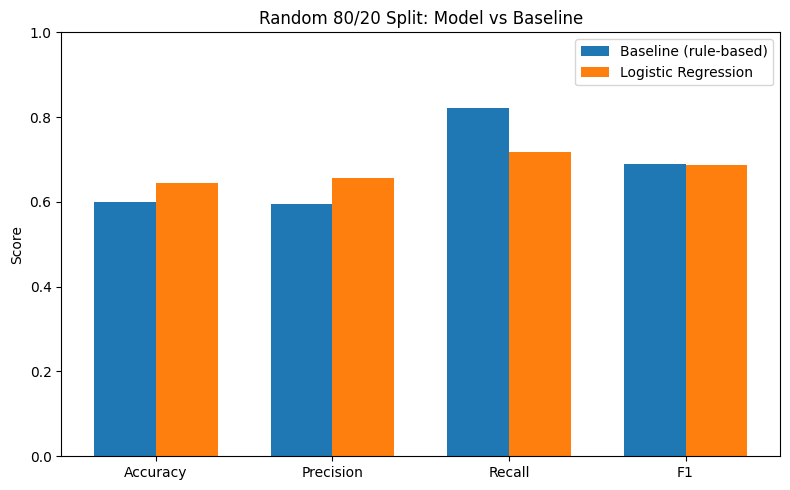

In [7]:
import matplotlib.pyplot as plt
import numpy as np

#Chart 1: Random split — Baseline vs Logistic Regression
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
baseline_scores = [0.599, 0.594, 0.822, 0.690]
lr_scores = [0.644, 0.657, 0.7175, 0.686]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, baseline_scores, width, label='Baseline (rule-based)')
ax.bar(x + width/2, lr_scores, width, label='Logistic Regression')

ax.set_ylabel('Score')
ax.set_title('Random 80/20 Split: Model vs Baseline')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig('random_split_comparison.png', dpi=150)
plt.show()

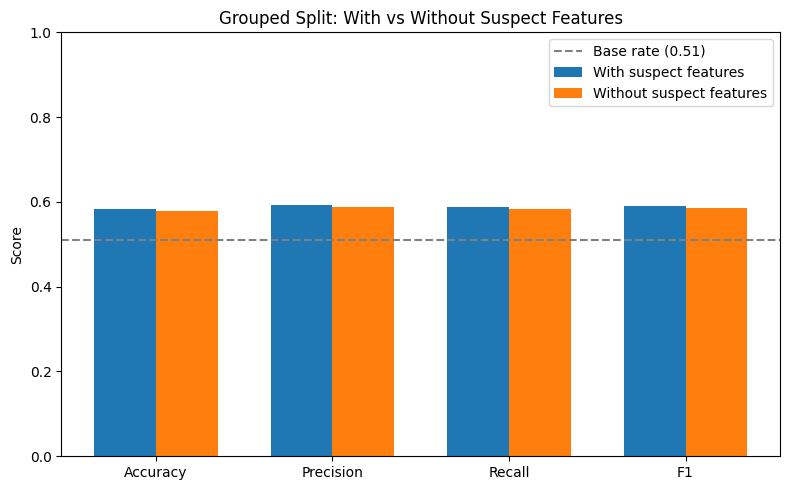

In [8]:
#Chart 2: Grouped split — With vs Without suspect features
metrics2 = ['Accuracy', 'Precision', 'Recall', 'F1']
with_suspects = [0.582671, 0.592143, 0.588758, 0.590446]
without_suspects = [0.577803, 0.587576, 0.582725, 0.585140]
base_rate = 0.510952

x2 = np.arange(len(metrics2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x2 - width/2, with_suspects, width, label='With suspect features')
ax.bar(x2 + width/2, without_suspects, width, label='Without suspect features')
ax.axhline(y=base_rate, color='gray', linestyle='--', label=f'Base rate ({base_rate:.2f})')

ax.set_ylabel('Score')
ax.set_title('Grouped Split: With vs Without Suspect Features')
ax.set_xticks(x2)
ax.set_xticklabels(metrics2)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig('grouped_split_comparison.png', dpi=150)
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.